In [10]:
#1.Imports
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
import scorecardpy as sc

In [11]:
#2.Loading the data
df = pd.read_csv("../data/raw/accepted_2007_to_2018Q4.csv")

C:\Users\BOSS\AppData\Local\Temp\ipykernel_6004\870440903.py:2: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/accepted_2007_to_2018Q4.csv")


In [12]:
#3.Exploring Data
df.head()


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print(df.shape)

(2260701, 151)


In [ ]:
#2.Loading the data
df = pd.read_csv("../Data/raw/accepted_2007_to_2018Q4.csv")

In [ ]:
len(df.columns)

151

In [ ]:
df.info

<bound method DataFrame.info of                                                        id  member_id  \
0                                                68407277        NaN   
1                                                68355089        NaN   
2                                                68341763        NaN   
3                                                66310712        NaN   
4                                                68476807        NaN   
...                                                   ...        ...   
2260696                                          88985880        NaN   
2260697                                          88224441        NaN   
2260698                                          88215728        NaN   
2260699  Total amount funded in policy code 1: 1465324575        NaN   
2260700   Total amount funded in policy code 2: 521953170        NaN   

         loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  \
0           3600.0       3600

In [ ]:
#4.Missing Values
missing=df.isnull().sum()
missing=missing[missing>0]
missing.sort_values(ascending=False).head(30)

member_id                                     2260701
orig_projected_additional_accrued_interest    2252050
hardship_payoff_balance_amount                2249784
hardship_last_payment_amount                  2249784
payment_plan_start_date                       2249784
hardship_type                                 2249784
hardship_status                               2249784
hardship_start_date                           2249784
deferral_term                                 2249784
hardship_amount                               2249784
hardship_dpd                                  2249784
hardship_loan_status                          2249784
hardship_length                               2249784
hardship_end_date                             2249784
hardship_reason                               2249784
debt_settlement_flag_date                     2226455
settlement_status                             2226455
settlement_percentage                         2226455
settlement_date             

In [ ]:
#5. Target Variable Analysis
df["loan_status"].value_counts(normalize=True)*(100)
sample_df = df.sample(n=100000, random_state=42)
print(sample_df.shape)



(100000, 151)


In [ ]:
sample_df.to_csv(
    "../data/processed/lendingclub_sample.csv",
    index=False
)

In [ ]:
important_cols=[
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "grade",
    "emp_length",
    "home_ownership",
    "purpose",
    "loan_status"
]

In [ ]:
sample_df[important_cols].head()

,loan_amnt,int_rate,annual_inc,dti,grade,emp_length,home_ownership,purpose,loan_status
392949,32000.0,10.49,120000.0,24.05,B,10+ years,MORTGAGE,debt_consolidation,Current
1273506,9600.0,12.99,21900.0,10.03,C,NaN,RENT,debt_consolidation,Fully Paid
324024,4000.0,6.68,83000.0,19.53,A,4 years,MORTGAGE,major_purchase,Fully Paid
2066630,6025.0,10.91,52000.0,9.16,B,10+ years,RENT,debt_consolidation,Fully Paid
477199,25000.0,26.30,65000.0,36.26,E,10+ years,OWN,debt_consolidation,Current


In [ ]:
missing = (
    sample_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing.head(20)

member_id                                     100000
orig_projected_additional_accrued_interest     99617
hardship_reason                                99510
hardship_payoff_balance_amount                 99510
hardship_last_payment_amount                   99510
payment_plan_start_date                        99510
hardship_type                                  99510
hardship_status                                99510
hardship_start_date                            99510
deferral_term                                  99510
hardship_amount                                99510
hardship_dpd                                   99510
hardship_loan_status                           99510
hardship_length                                99510
hardship_end_date                              99510
settlement_status                              98415
debt_settlement_flag_date                      98415
settlement_term                                98415
settlement_percentage                         

In [ ]:
sample_df.to_csv(
    "../Data/processed/lendingclub_sample.csv",
    index=False
)

<Axes: >

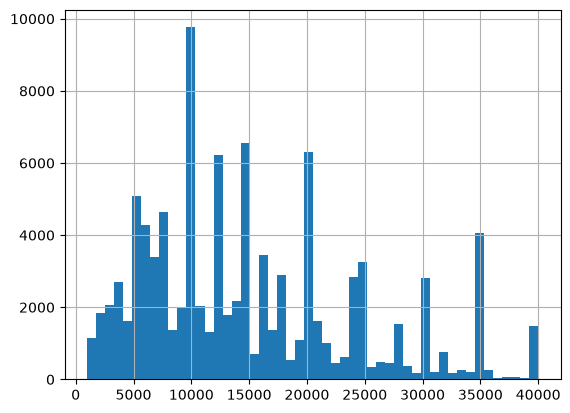

In [ ]:
sample_df["loan_amnt"].hist(bins=50)

<Axes: >

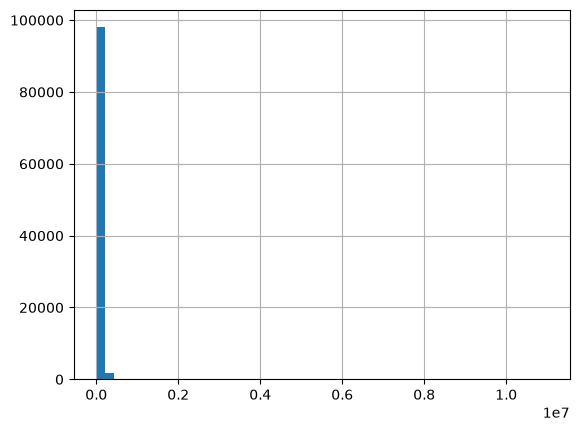

In [ ]:
sample_df["annual_inc"].hist(bins=50)   

In [ ]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [ ]:
risk_df = sample_df[sample_df["loan_status"].isin(["Charged Off","Default","Fully Paid"])].copy()
risk_df["target"] = risk_df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1
})

In [ ]:
risk_df["target"].value_counts()

target
0    47460
1    12034
Name: count, dtype: int64

In [ ]:
risk_df.to_csv(
    "../data/processed/risk_model_base.csv",
    index=False
)

In [ ]:
data_dictionary = pd.DataFrame({
    "column": risk_df.columns,
    "dtype": risk_df.dtypes.astype(str)
})

data_dictionary.to_csv(
    "../data/processed/risk_model_data_dictionary.csv",
    index=False
)

In [ ]:
missing_pct = (
    risk_df.isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing_pct.head(30)

member_id                                     100.000000
next_pymnt_d                                  100.000000
orig_projected_additional_accrued_interest     99.737789
hardship_amount                                99.584832
hardship_last_payment_amount                   99.584832
hardship_length                                99.584832
hardship_status                                99.584832
hardship_reason                                99.584832
deferral_term                                  99.584832
hardship_start_date                            99.584832
hardship_end_date                              99.584832
hardship_type                                  99.584832
hardship_loan_status                           99.584832
hardship_payoff_balance_amount                 99.584832
hardship_dpd                                   99.584832
payment_plan_start_date                        99.584832
sec_app_mths_since_last_major_derog            99.497428
sec_app_revol_util             

In [ ]:
missing_df= pd.DataFrame({
    "column":risk_df.columns,
    "missing_pct":risk_df.isnull().mean()*100
})

missing_df=missing_df.sort_values(by="missing_pct",ascending=False)

missing_df.head(30)

,column,missing_pct
member_id,member_id,100.000000
next_pymnt_d,next_pymnt_d,100.000000
orig_projected_additional_accrued_interest,orig_projected_additional_accrued_interest,99.737789
hardship_amount,hardship_amount,99.584832
hardship_last_payment_amount,hardship_last_payment_amount,99.584832
hardship_length,hardship_length,99.584832
hardship_status,hardship_status,99.584832
hardship_reason,hardship_reason,99.584832
deferral_term,deferral_term,99.584832
hardship_start_date,hardship_start_date,99.584832


In [ ]:
missing_df.to_csv(
    "../data/processed/missing_value_report.csv",
    index=False
)

In [ ]:
[col for col in risk_df.columns if "recover" in col.lower()]

['recoveries', 'collection_recovery_fee']

In [ ]:
[col for col in risk_df.columns if "payment" in col.lower()]

['payment_plan_start_date', 'hardship_last_payment_amount']

In [ ]:
[col for col in risk_df.columns if "last_" in col.lower()]

['inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'mths_since_last_major_derog',
 'inq_last_12m',
 'sec_app_inq_last_6mths',
 'sec_app_mths_since_last_major_derog',
 'hardship_last_payment_amount']

In [ ]:
[col for col in risk_df.columns if "out_prncp" in col.lower()]

['out_prncp', 'out_prncp_inv']

In [ ]:
[col for col in risk_df.columns if "total_rec" in col.lower()]

['total_rec_prncp', 'total_rec_int', 'total_rec_late_fee']

In [ ]:
leakage_cols = [
    "recoveries",
    "collection_recovery_fee",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "out_prncp",
    "out_prncp_inv",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "last_credit_pull_d",
    "last_fico_range_high",
    "last_fico_range_low",
    "payment_plan_start_date",
    "hardship_last_payment_amount"
]

In [ ]:
risk_df_clean = risk_df.drop(
    columns=leakage_cols,
    errors="ignore"
)

In [ ]:
risk_df_clean.shape

(59494, 138)

In [ ]:
candidate_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "open_acc",
    "revol_bal",
    "revol_util",
    "delinq_2yrs",
    "pub_rec",
    "inq_last_6mths",
    "target"
]

for col in candidate_features:
    print(col, col in risk_df_clean.columns)

loan_amnt True
term True
int_rate True
grade True
sub_grade True
emp_length True
home_ownership True
annual_inc True
verification_status True
purpose True
dti True
fico_range_low True
fico_range_high True
open_acc True
revol_bal True
revol_util True
delinq_2yrs True
pub_rec True
inq_last_6mths True
target True


In [ ]:
model_df = risk_df_clean[
    candidate_features
].copy()

In [ ]:
model_df.info()

<class 'pandas.DataFrame'>
Index: 59494 entries, 1273506 to 347653
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_amnt            59494 non-null  float64
 1   term                 59494 non-null  str    
 2   int_rate             59494 non-null  float64
 3   grade                59494 non-null  str    
 4   sub_grade            59494 non-null  str    
 5   emp_length           56024 non-null  str    
 6   home_ownership       59494 non-null  str    
 7   annual_inc           59494 non-null  float64
 8   verification_status  59494 non-null  str    
 9   purpose              59494 non-null  str    
 10  dti                  59474 non-null  float64
 11  fico_range_low       59494 non-null  float64
 12  fico_range_high      59494 non-null  float64
 13  open_acc             59494 non-null  float64
 14  revol_bal            59494 non-null  float64
 15  revol_util           59462 non-null  float64


In [ ]:
model_df.isnull().sum()

loan_amnt                 0
term                      0
int_rate                  0
grade                     0
sub_grade                 0
emp_length             3470
home_ownership            0
annual_inc                0
verification_status       0
purpose                   0
dti                      20
fico_range_low            0
fico_range_high           0
open_acc                  0
revol_bal                 0
revol_util               32
delinq_2yrs               0
pub_rec                   0
inq_last_6mths            0
target                    0
dtype: int64

In [ ]:
model_df["emp_length"].value_counts(dropna=False)

emp_length
10+ years    19537
2 years       5449
< 1 year      4851
3 years       4705
1 year        3852
5 years       3682
4 years       3602
NaN           3470
6 years       2778
7 years       2683
8 years       2647
9 years       2238
Name: count, dtype: int64

In [ ]:
model_df["emp_length"]=(model_df["emp_length"].fillna("missing"))

In [ ]:
model_df["dti"]=(model_df["dti"].fillna(model_df["dti"].median()))

In [ ]:
model_df.isnull().sum()

loan_amnt               0
term                    0
int_rate                0
grade                   0
sub_grade               0
emp_length              0
home_ownership          0
annual_inc              0
verification_status     0
purpose                 0
dti                     0
fico_range_low          0
fico_range_high         0
open_acc                0
revol_bal               0
revol_util             32
delinq_2yrs             0
pub_rec                 0
inq_last_6mths          0
target                  0
dtype: int64

In [ ]:
model_df["revol_util"] = model_df["revol_util"].fillna(
    model_df["revol_util"].median()
)

In [ ]:
model_df.isnull().sum()

loan_amnt              0
term                   0
int_rate               0
grade                  0
sub_grade              0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
fico_range_low         0
fico_range_high        0
open_acc               0
revol_bal              0
revol_util             0
delinq_2yrs            0
pub_rec                0
inq_last_6mths         0
target                 0
dtype: int64

In [ ]:
model_df["revol_util"].dtype

dtype('float64')

In [ ]:
model_df.info()

<class 'pandas.DataFrame'>
Index: 59494 entries, 1273506 to 347653
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_amnt            59494 non-null  float64
 1   term                 59494 non-null  str    
 2   int_rate             59494 non-null  float64
 3   grade                59494 non-null  str    
 4   sub_grade            59494 non-null  str    
 5   emp_length           59494 non-null  str    
 6   home_ownership       59494 non-null  str    
 7   annual_inc           59494 non-null  float64
 8   verification_status  59494 non-null  str    
 9   purpose              59494 non-null  str    
 10  dti                  59494 non-null  float64
 11  fico_range_low       59494 non-null  float64
 12  fico_range_high      59494 non-null  float64
 13  open_acc             59494 non-null  float64
 14  revol_bal            59494 non-null  float64
 15  revol_util           59494 non-null  float64


In [ ]:
iv=sc.iv(
    dt= model_df,
    y="target"
)

In [ ]:
iv.sort_values(by="info_value", ascending=False)

,variable,info_value
9,int_rate,0.569668
17,sub_grade,0.496593
3,grade,0.455679
8,dti,0.439192
7,revol_bal,0.380001
4,annual_inc,0.316466
0,loan_amnt,0.196713
12,term,0.183950
6,revol_util,0.151781
16,fico_range_high,0.131421


In [ ]:
model_df = pd.read_csv("../Data/processed/model_df_clean.csv")
model_df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,59494.0,14398.486402,8736.254347,1000.00,7925.00,12000.00,20000.00,40000.00
int_rate,59494.0,13.301648,4.792188,5.31,9.75,12.79,16.02,30.99
annual_inc,59494.0,76349.792171,84175.706672,0.00,45466.25,65000.00,90000.00,10999200.00
dti,59494.0,18.289734,11.250554,0.00,11.75,17.66,24.06,999.00
fico_range_low,59494.0,695.773103,31.667783,660.00,670.00,690.00,710.00,845.00
fico_range_high,59494.0,699.773305,31.668737,664.00,674.00,694.00,714.00,850.00
open_acc,59494.0,11.600682,5.476655,1.00,8.00,11.00,14.00,64.00
revol_bal,59494.0,16161.873315,21543.393974,0.00,5953.00,11138.50,19710.75,777448.00
revol_util,59494.0,51.952600,24.586064,0.00,33.50,52.40,71.00,146.10
delinq_2yrs,59494.0,0.317477,0.866721,0.00,0.00,0.00,0.00,20.00


In [ ]:
model_df.to_csv(
    "../data/processed/model_df_clean.csv",
    index=False
)

In [ ]:
model_df["target"].value_counts(normalize=True) * 100

target
0    79.77275
1    20.22725
Name: proportion, dtype: float64

In [ ]:
bins = sc.woebin(
    model_df,
    y="target"
)

[INFO] creating woe binning ...
Binning on 59494 rows and 20 columns in 00:00:14


In [ ]:
model_woe = sc.woebin_ply(
    model_df,
    bins
)

[INFO] converting into woe values ...


In [ ]:
iv = sc.iv(model_df, y="target")
iv.sort_values(by="info_value", ascending=False)

,variable,info_value
11,int_rate,0.569668
4,sub_grade,0.496593
3,grade,0.455679
2,dti,0.439192
15,revol_bal,0.380001
12,annual_inc,0.316466
17,loan_amnt,0.196713
1,term,0.183950
14,revol_util,0.151781
7,fico_range_low,0.131421


In [ ]:
bins["annual_inc"]

,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,annual_inc,"[-inf,45000.0)",13376,0.224829,10216,3160,0.236244,0.198768,9.408568e-03,0.025945,45000.0,False
1,annual_inc,"[45000.0,60000.0)",11672,0.196188,9115,2557,0.219071,0.101065,2.064227e-03,0.025945,60000.0,False
2,annual_inc,"[60000.0,75000.0)",10896,0.183145,8694,2202,0.202093,-0.001116,2.279491e-07,0.025945,75000.0,False
3,annual_inc,"[75000.0,90000.0)",7655,0.128668,6192,1463,0.191117,-0.070618,6.281837e-04,0.025945,90000.0,False
4,annual_inc,"[90000.0,inf)",15895,0.267170,13243,2652,0.166845,-0.236004,1.384383e-02,0.025945,inf,False


In [ ]:
bins["dti"]

,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,dti,"[-inf,14.0)",20317,0.341497,17189,3128,0.153960,-0.331725,0.033918,0.076181,14.0,False
1,dti,"[14.0,18.0)",10282,0.172824,8445,1837,0.178662,-0.153289,0.003876,0.076181,18.0,False
2,dti,"[18.0,28.0)",20542,0.345279,15803,4739,0.230698,0.167778,0.010205,0.076181,28.0,False
3,dti,"[28.0,inf)",8353,0.140401,6023,2330,0.278942,0.422434,0.028181,0.076181,inf,False


{'term': <Figure size 640x480 with 2 Axes>,
 'open_acc': <Figure size 640x480 with 2 Axes>,
 'purpose': <Figure size 640x480 with 2 Axes>,
 'pub_rec': <Figure size 640x480 with 2 Axes>,
 'emp_length': <Figure size 640x480 with 2 Axes>,
 'int_rate': <Figure size 640x480 with 2 Axes>,
 'grade': <Figure size 640x480 with 2 Axes>,
 'inq_last_6mths': <Figure size 640x480 with 2 Axes>,
 'dti': <Figure size 640x480 with 2 Axes>,
 'revol_bal': <Figure size 640x480 with 2 Axes>,
 'fico_range_low': <Figure size 640x480 with 2 Axes>,
 'revol_util': <Figure size 640x480 with 2 Axes>,
 'home_ownership': <Figure size 640x480 with 2 Axes>,
 'loan_amnt': <Figure size 640x480 with 2 Axes>,
 'fico_range_high': <Figure size 640x480 with 2 Axes>,
 'delinq_2yrs': <Figure size 640x480 with 2 Axes>,
 'verification_status': <Figure size 640x480 with 2 Axes>,
 'sub_grade': <Figure size 640x480 with 2 Axes>,
 'annual_inc': <Figure size 640x480 with 2 Axes>}

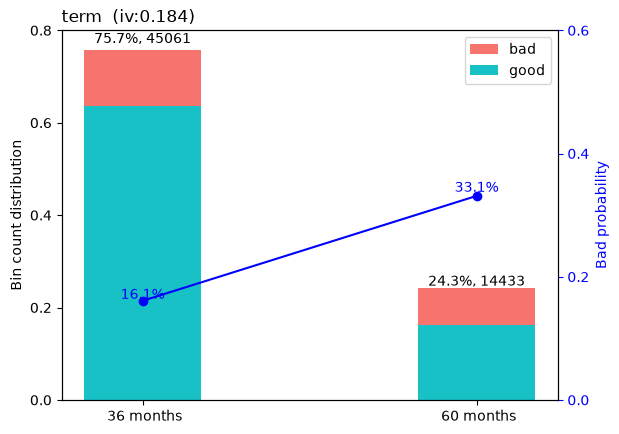

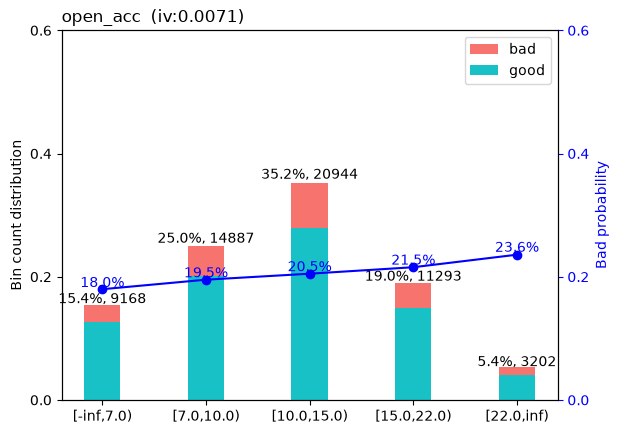

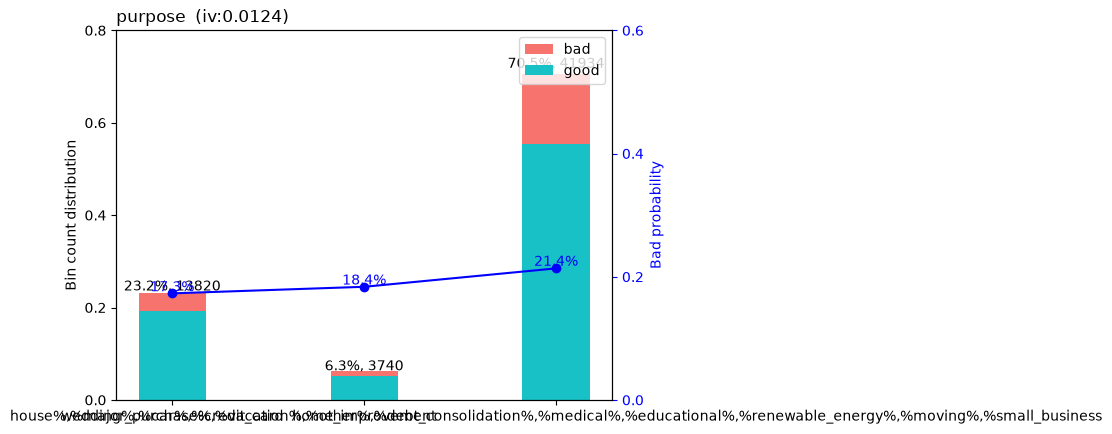

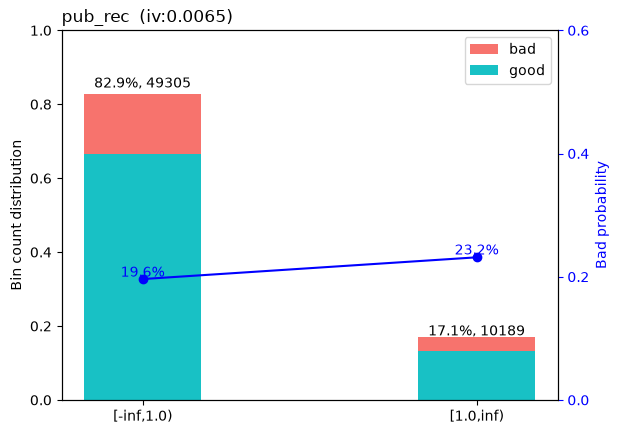

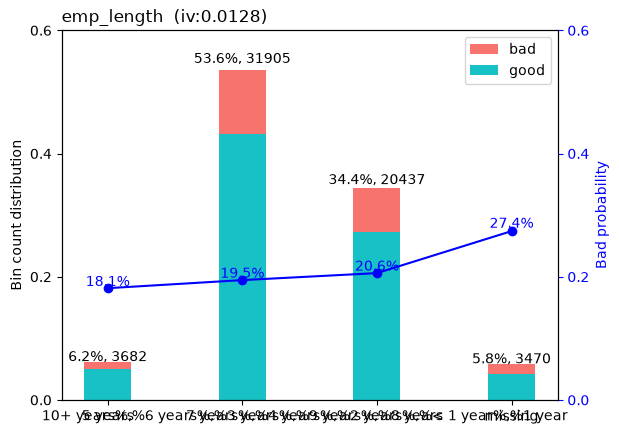

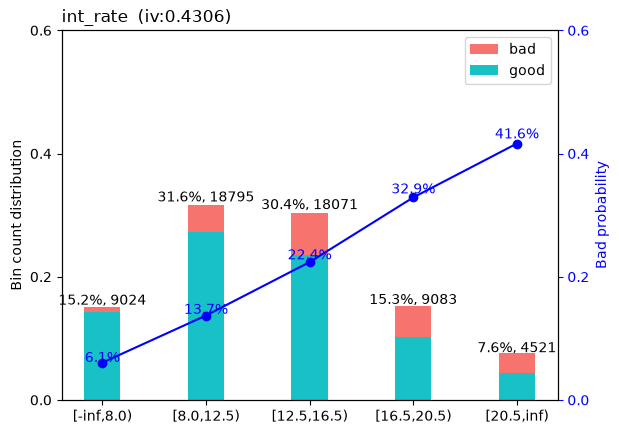

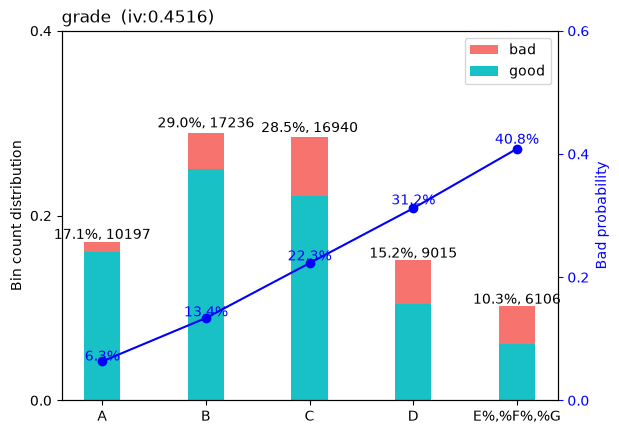

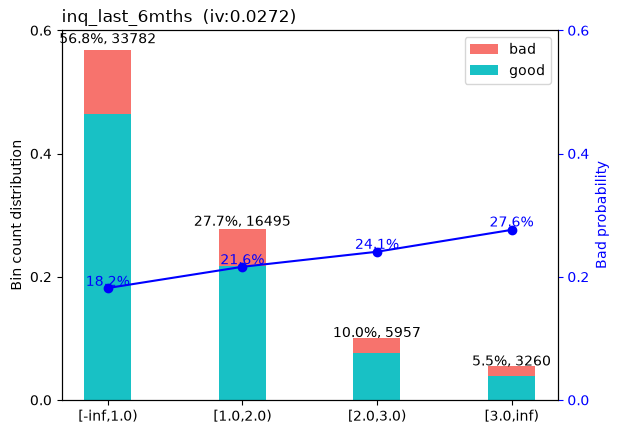

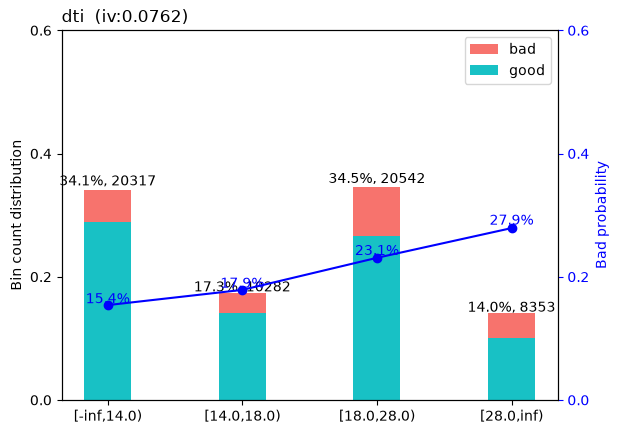

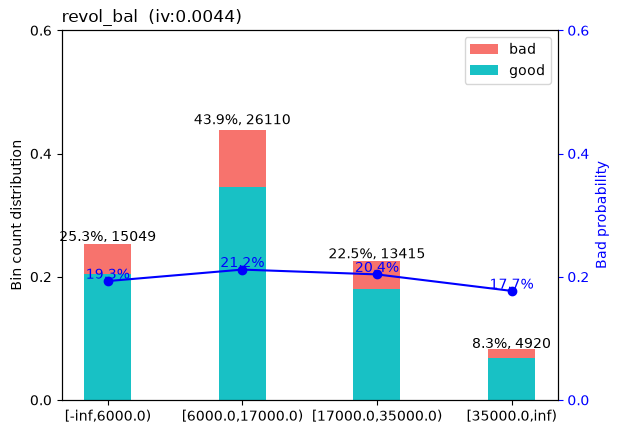

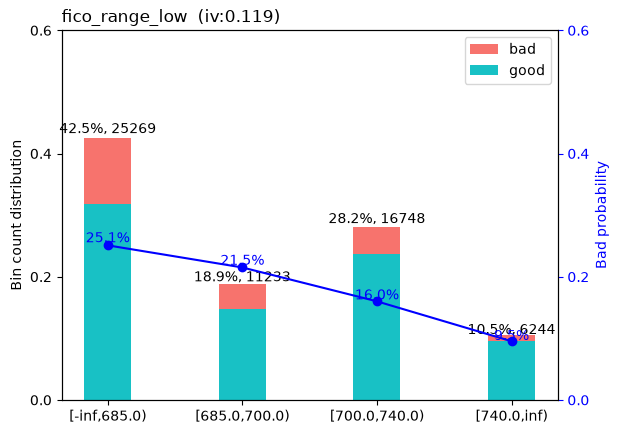

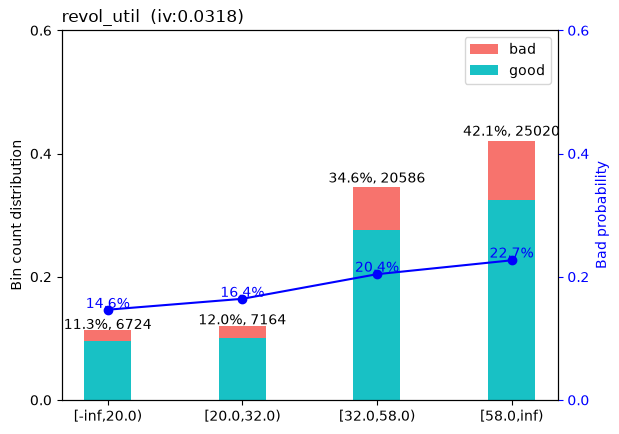

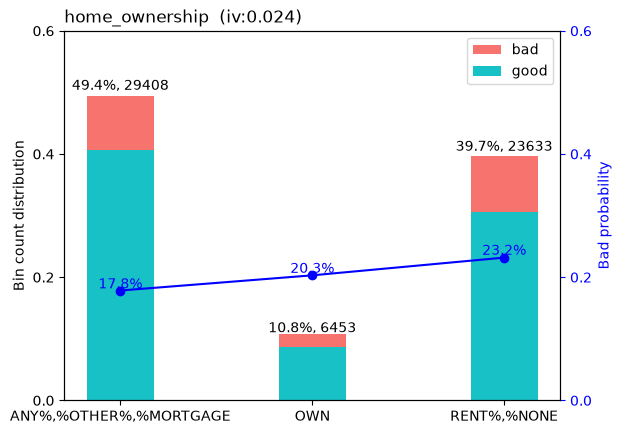

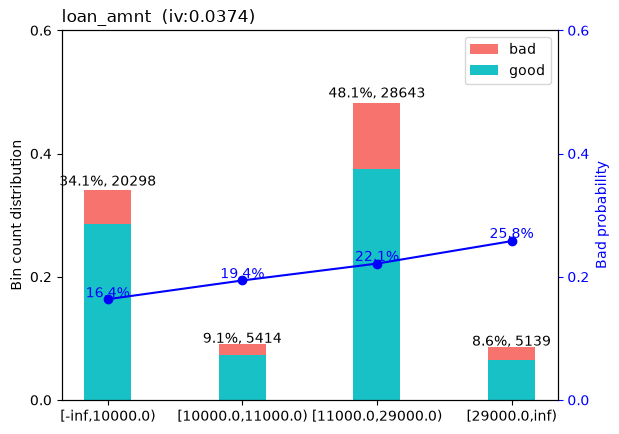

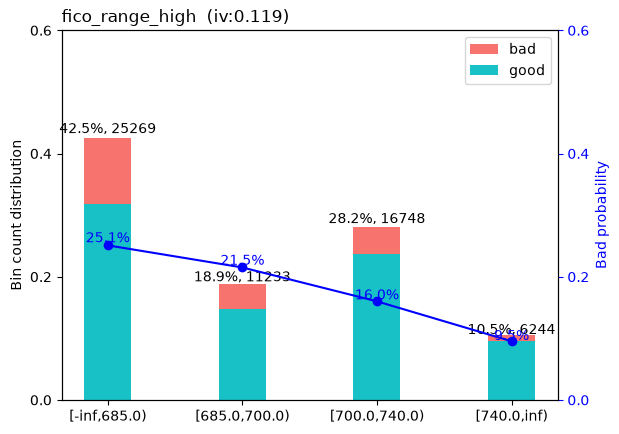

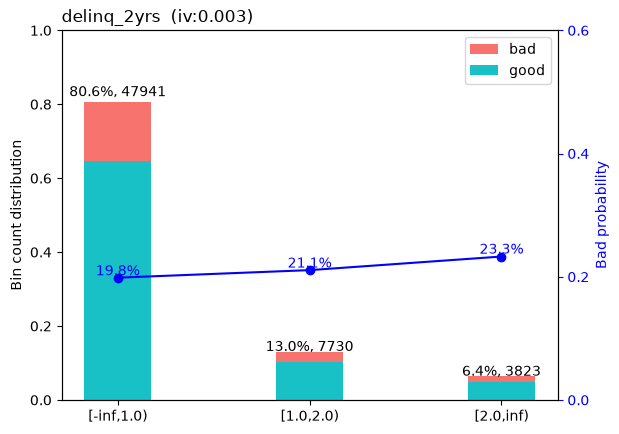

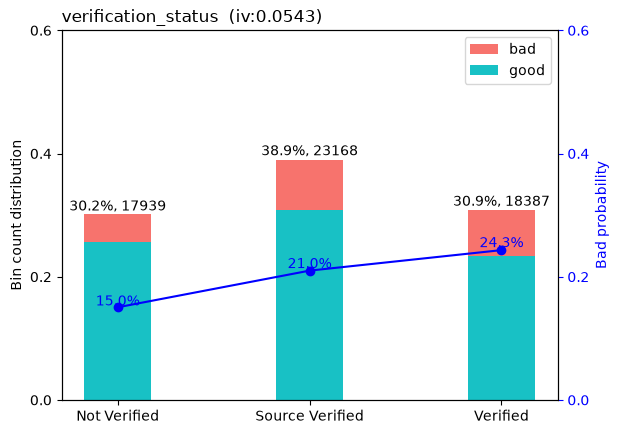

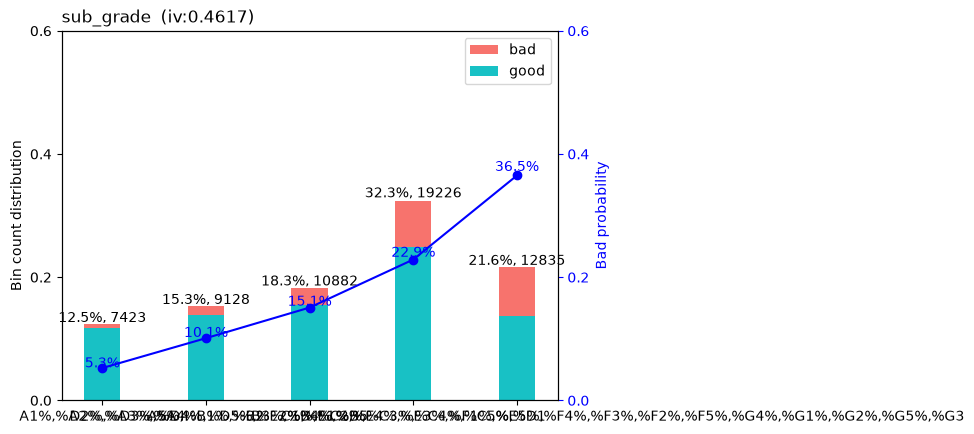

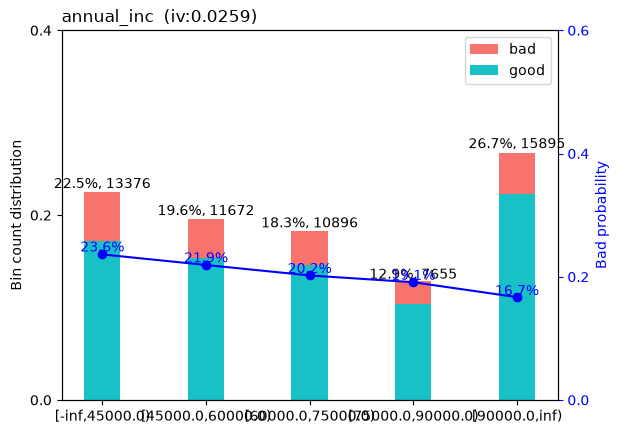

In [ ]:
sc.woebin_plot(bins)

In [ ]:
print(f"Type of bins: {type(bins)}")
print(f"Keys in bins: {list(bins.keys())[:3]}")  # First 3 keys
if isinstance(bins, dict):
    print(f"Type of first value: {type(list(bins.values())[0])}")
    print(f"Columns in first value: {list(bins.values())[0].columns}")
    # Try the concat manually
    test_concat = pd.concat(list(bins.values()), ignore_index=True)
    print(f"After concat, shape: {test_concat.shape}")
    print(f"After concat, columns: {list(test_concat.columns)}")
    print(f"'variable' in columns: {'variable' in test_concat.columns}")

Type of bins: <class 'dict'>
Keys in bins: ['pub_rec', 'open_acc', 'delinq_2yrs']
Type of first value: <class 'pandas.DataFrame'>
Columns in first value: Index(['variable', 'bin', 'count', 'count_distr', 'good', 'bad', 'badprob',
       'woe', 'bin_iv', 'total_iv', 'breaks', 'is_special_values'],
      dtype='str')
After concat, shape: (73, 12)
After concat, columns: ['variable', 'bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'bin_iv', 'total_iv', 'breaks', 'is_special_values']
'variable' in columns: True


In [ ]:
# Ensure `model_woe` exists in the kernel
if 'model_woe' not in globals():
    model_woe = sc.woebin_ply(model_df, bins=bins)
print('model_woe created:', isinstance(model_woe, pd.DataFrame), 'shape=', getattr(model_woe, 'shape', None))
model_woe.head()

model_woe created: True shape= (59494, 20)


,target,open_acc_woe,pub_rec_woe,grade_woe,inq_last_6mths_woe,revol_bal_woe,revol_util_woe,fico_range_high_woe,verification_status_woe,sub_grade_woe,annual_inc_woe,term_woe,purpose_woe,emp_length_woe,int_rate_woe,dti_woe,fico_range_low_woe,home_ownership_woe,loan_amnt_woe,delinq_2yrs_woe
0,0,0.016374,0.172427,0.123331,0.083765,-0.058677,0.011407,0.077583,0.237020,0.156194,0.198768,-0.278954,0.068634,0.398048,0.128402,-0.331725,0.077583,0.173945,-0.260162,-0.023714
1,0,0.079730,-0.037890,-1.321450,-0.133157,-0.058677,-0.390247,-0.878521,-0.359327,-1.520071,-0.070618,-0.278954,0.068634,0.022339,-1.370460,0.167778,-0.878521,-0.155164,-0.260162,-0.023714
2,0,0.016374,-0.037890,-0.495707,0.083765,-0.058677,-0.390247,-0.878521,-0.359327,-0.356911,0.101065,-0.278954,0.068634,-0.048584,-0.467794,-0.331725,-0.878521,0.173945,-0.260162,0.051665
3,0,0.079730,-0.037890,-0.495707,-0.133157,0.009451,0.011407,0.077583,-0.359327,-0.813924,-0.236004,-0.278954,0.068634,-0.048584,-0.467794,-0.153289,0.077583,-0.155164,0.114309,0.051665
4,0,-0.145852,-0.037890,-0.495707,-0.133157,-0.058677,0.144876,0.278756,0.237020,-0.813924,0.198768,-0.278954,0.068634,0.398048,-0.467794,-0.153289,0.278756,0.173945,-0.260162,0.051665


In [ ]:
bins = sc.woebin(model_df, y="target")

[INFO] creating woe binning ...
Binning on 59494 rows and 20 columns in 00:00:13


In [ ]:
bins["revol_util"]

,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,revol_util,"[-inf,20.0)",6724,0.113020,5739,985,0.146490,-0.390247,0.015248,0.031768,20.0,False
1,revol_util,"[20.0,32.0)",7164,0.120416,5988,1176,0.164154,-0.255487,0.007268,0.031768,32.0,False
2,revol_util,"[32.0,58.0)",20586,0.346018,16384,4202,0.204119,0.011407,0.000045,0.031768,58.0,False
3,revol_util,"[58.0,inf)",25020,0.420547,19349,5671,0.226659,0.144876,0.009208,0.031768,inf,False


In [ ]:
bins["fico_range_low"]

,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,fico_range_low,"[-inf,685.0)",25269,0.424732,18927,6342,0.250979,0.278756,0.035739,0.119047,685.0,False
1,fico_range_low,"[685.0,700.0)",11233,0.188809,8817,2416,0.215081,0.077583,0.001163,0.119047,700.0,False
2,fico_range_low,"[700.0,740.0)",16748,0.281507,14067,2681,0.160079,-0.285490,0.021015,0.119047,740.0,False
3,fico_range_low,"[740.0,inf)",6244,0.104952,5649,595,0.095291,-0.878521,0.061130,0.119047,inf,False


In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    model_woe,
    test_size=0.3,
    random_state=42,
    stratify=model_woe["target"]
)

In [ ]:
# Ensure `train_df` and `test_df` exist (alias from `train` / `test` if present)
if 'train_df' not in globals():
    if 'train' in globals():
        train_df = train.copy()
        print("Created alias train_df from train")
    else:
        print("Warning: 'train' not found in globals; create train_df manually")
if 'test_df' not in globals():
    if 'test' in globals():
        test_df = test.copy()
        print("Created alias test_df from test")
    else:
        print("Warning: 'test' not found in globals; create test_df manually")
print('train_df/test_df defined:', 'train_df' in globals(), 'test_df' in globals())

Created alias train_df from train
Created alias test_df from test
train_df/test_df defined: True True


In [ ]:
train_df.shape, test_df.shape

((41645, 20), (17849, 20))

In [ ]:
x_cols = [
    col for col in train_df.columns
    if col != "target"
]

In [ ]:
X_train = train_df[x_cols]
y_train = train_df["target"]

X_test = test_df[x_cols]
y_test = test_df["target"]

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
pred_prob = lr.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    pred_prob
)

print(auc)

0.7048450872024651


In [ ]:
from scipy.stats import ks_2samp

good = pred_prob[y_test == 0]
bad = pred_prob[y_test == 1]

ks = ks_2samp(
    good,
    bad
)

print(ks.statistic)

0.30065636515060756


In [ ]:
from scipy.stats import ks_2samp

good = pred_prob[y_test == 0]
bad = pred_prob[y_test == 1]

ks = ks_2samp(
    good,
    bad
)

print(ks.statistic)

0.30065636515060756


In [ ]:
reduced_features = [
    col for col in X_train.columns
    if "grade" not in col.lower()
]

In [ ]:
import os
import pandas as pd
import numpy as np
import scorecardpy as sc
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

# Load data (try common paths)
try:
    model_df = pd.read_csv(os.path.join('..', 'Data', 'processed', 'model_df.csv'))
except Exception:
    try:
        model_df = pd.read_csv(os.path.join('..', 'Data', 'processed', 'model_df_clean.csv'))
    except Exception:
        model_df = pd.read_csv(os.path.join('..', 'data', 'processed', 'model_df.csv'))

print('Loaded model_df shape:', model_df.shape)

# Missing value treatment
model_df['emp_length'] = model_df['emp_length'].fillna('Missing')
model_df['dti'] = model_df['dti'].fillna(model_df['dti'].median())
model_df['revol_util'] = model_df['revol_util'].fillna(model_df['revol_util'].median())

print('Missing values after treatment:')
print(model_df.isnull().sum())

# Information value
iv = sc.iv(dt=model_df, y='target')
iv = iv.sort_values(by='info_value', ascending=False)
print(iv)

# ensure output directories
output_dir = os.path.join('..', 'Data', 'processed')
models_dir = os.path.join('..', 'models')
os.makedirs(output_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

# WOE binning
bins = sc.woebin(model_df, y='target')
print('Binning done for', len(bins), 'variables')

# save bins
joblib.dump(bins, os.path.join(models_dir, 'woe_bins.pkl'))

# WOE transformation
model_woe = sc.woebin_ply(model_df, bins)
print('model_woe shape:', model_woe.shape)

# Train test split
train_df, test_df = train_test_split(
    model_woe,
    test_size=0.30,
    random_state=42,
    stratify=model_woe['target']
)
print('Train Shape:', train_df.shape)
print('Test Shape:', test_df.shape)

# Features and target
X_train = train_df.drop(columns=['target'])
y_train = train_df['target']
X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

# Train logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
joblib.dump(lr, os.path.join(models_dir, 'logistic_model.pkl'))

# Predictions
pred_prob = lr.predict_proba(X_test)[:, 1]

# Metrics
auc = roc_auc_score(y_test, pred_prob)
print(f'ROC-AUC Score: {auc:.4f}')

good = pred_prob[y_test == 0]
bad = pred_prob[y_test == 1]
ks = ks_2samp(good, bad)
print(f'KS Statistic: {ks.statistic:.4f}')

# Coefficients
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values(by='coefficient', ascending=False)
print(coef_df.head(15))

# Scoring dataset
test_results = pd.DataFrame({
    'actual': y_test,
    'probability_of_default': pred_prob
})

# Risk bands
test_results['risk_band'] = pd.qcut(
    test_results['probability_of_default'],
    q=5,
    labels=['Very Low Risk', 'Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)

# Decision rule
def decision(pd_value):
    if pd_value < 0.10:
        return 'Approve'
    elif pd_value < 0.25:
        return 'Manual Review'
    return 'Reject'

test_results['decision'] = test_results['probability_of_default'].apply(decision)

# Credit score (300-850)
test_results['credit_score'] = (850 - (test_results['probability_of_default'] * 550)).round().astype(int)

# Save outputs
model_woe.to_csv(os.path.join(output_dir, 'model_woe.csv'), index=False)
coef_df.to_csv(os.path.join(output_dir, 'model_coefficients.csv'), index=False)
iv.to_csv(os.path.join(output_dir, 'information_value.csv'), index=False)
test_results.to_csv(os.path.join(output_dir, 'scored_loans.csv'), index=False)

print('\nPipeline Completed Successfully')

Loaded model_df shape: (59494, 20)
Missing values after treatment:
loan_amnt              0
term                   0
int_rate               0
grade                  0
sub_grade              0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
fico_range_low         0
fico_range_high        0
open_acc               0
revol_bal              0
revol_util             0
delinq_2yrs            0
pub_rec                0
inq_last_6mths         0
target                 0
dtype: int64
               variable  info_value
5              int_rate    0.569668
17            sub_grade    0.496593
6                 grade    0.455679
8                   dti    0.439192
9             revol_bal    0.380001
18           annual_inc    0.316466
13            loan_amnt    0.196713
0                  term    0.183950
11           revol_util    0.151781
14      fico_range_high    0.131421
10       fico_range_low 

<Axes: >

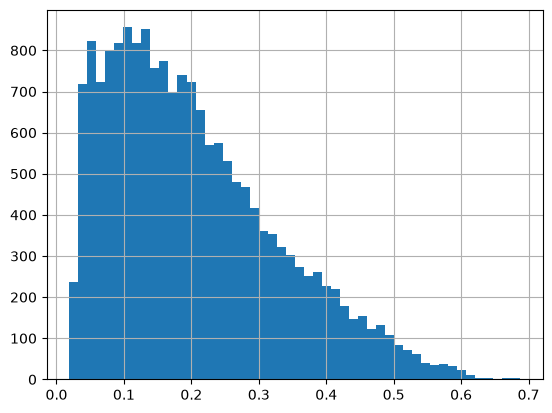

In [ ]:
pd.Series(pred_prob).hist(bins=50)

In [ ]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print(project_root)

c:\Users\BOSS\OneDrive\Desktop\Credit Card Score Builder


In [ ]:
from apps.utils.scoring import score_applicant
import pandas as pd

In [ ]:
input_df = pd.DataFrame({
    "loan_amnt":[10000],
    "term":["36 months"],
    "int_rate":[10.0],
    "grade":["B"],
    "sub_grade":["B1"],
    "emp_length":["10+ years"],
    "home_ownership":["RENT"],
    "annual_inc":[60000],
    "verification_status":["Verified"],
    "purpose":["debt_consolidation"],
    "dti":[15],
    "fico_range_low":[700],
    "fico_range_high":[704],
    "open_acc":[10],
    "revol_bal":[10000],
    "revol_util":[45],
    "delinq_2yrs":[0],
    "pub_rec":[0],
    "inq_last_6mths":[1],
    "unrate":[4.2],
    "fedfunds":[4.5],
    "cpi":[320],
    "target":[0]
})

In [ ]:
score_applicant(input_df)

[INFO] converting into woe values ...


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- target
